In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import os
import time

from sklearn.model_selection import StratifiedKFold
import optuna
from qiskit.circuit.library import ZZFeatureMap

from qiskit_machine_learning.kernels import FidelityQuantumKernel
from qiskit_machine_learning.algorithms import PegasosQSVC

from sklearn.metrics import f1_score
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score, accuracy_score, classification_report
from sklearn.preprocessing import LabelEncoder


In [2]:
# Definir la ruta base de los archivos de datos
base_dir = r"/home/daniel/Desktop/TFG/nsl-kdd"

# Definir las rutas completas de los archivos de entrenamiento y prueba
train_path = os.path.join(base_dir, "KDDTrain+.txt")
test_path = os.path.join(base_dir, "KDDTest+.txt")

# Nombres de las columnas
column_names = [
    "duration", "protocol_type", "service", "flag", "src_bytes", "dst_bytes",
    "land", "wrong_fragment", "urgent", "hot", "num_failed_logins",
    "logged_in", "num_compromised", "root_shell", "su_attempted", "num_root",
    "num_file_creations", "num_shells", "num_access_files", "num_outbound_cmds",
    "is_host_login", "is_guest_login", "count", "srv_count", "serror_rate",
    "srv_serror_rate", "rerror_rate", "srv_rerror_rate", "same_srv_rate",
    "diff_srv_rate", "srv_diff_host_rate", "dst_host_count", "dst_host_srv_count",
    "dst_host_same_srv_rate", "dst_host_diff_srv_rate", "dst_host_same_src_port_rate",
    "dst_host_srv_diff_host_rate", "dst_host_serror_rate", "dst_host_srv_serror_rate",
    "dst_host_rerror_rate", "dst_host_srv_rerror_rate", "label", "difficulty"
]

# Cargar los datos en dataframes
train = pd.read_csv(train_path, names=column_names)
test = pd.read_csv(test_path, names=column_names)

# Añadir la columna 'class': 0 para normal, 1 para anomalía
train['class'] = train['label'].apply(lambda x: 0 if x == 'normal' else 1)
test['class'] = test['label'].apply(lambda x: 0 if x == 'normal' else 1)

# Mostrar las primeras líneas del dataframe de entrenamientotrain.head()
train.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label,difficulty,class
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20,0
1,0,udp,other,SF,146,0,0,0,0,0,...,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15,0
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19,1
3,0,tcp,http,SF,232,8153,0,0,0,0,...,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21,0
4,0,tcp,http,SF,199,420,0,0,0,0,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21,0


In [3]:
train.info() #Información sobre el dataframe de entrenamiento

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125973 entries, 0 to 125972
Data columns (total 44 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   duration                     125973 non-null  int64  
 1   protocol_type                125973 non-null  object 
 2   service                      125973 non-null  object 
 3   flag                         125973 non-null  object 
 4   src_bytes                    125973 non-null  int64  
 5   dst_bytes                    125973 non-null  int64  
 6   land                         125973 non-null  int64  
 7   wrong_fragment               125973 non-null  int64  
 8   urgent                       125973 non-null  int64  
 9   hot                          125973 non-null  int64  
 10  num_failed_logins            125973 non-null  int64  
 11  logged_in                    125973 non-null  int64  
 12  num_compromised              125973 non-null  int64  
 13 

In [4]:
train.describe() #Driscripciones del dataframe de entrenamiento para columnas numéricas


,duration,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,difficulty,class
count,125973.00000,1.259730e+05,1.259730e+05,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,...,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000
mean,287.14465,4.556674e+04,1.977911e+04,0.000198,0.022687,0.000111,0.204409,0.001222,0.395736,0.279250,...,0.521242,0.082951,0.148379,0.032542,0.284452,0.278485,0.118832,0.120240,19.504060,0.465417
std,2604.51531,5.870331e+06,4.021269e+06,0.014086,0.253530,0.014366,2.149968,0.045239,0.489010,23.942042,...,0.448949,0.188922,0.308997,0.112564,0.444784,0.445669,0.306557,0.319459,2.291503,0.498805
min,0.00000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.00000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.050000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,18.000000,0.000000
50%,0.00000,4.400000e+01,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.510000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,20.000000,0.000000
75%,0.00000,2.760000e+02,5.160000e+02,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,...,1.000000,0.070000,0.060000,0.020000,1.000000,1.000000,0.000000,0.000000,21.000000,1.000000
max,42908.00000,1.379964e+09,1.309937e+09,1.000000,3.000000,3.000000,77.000000,5.000000,1.000000,7479.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,21.000000,1.000000


In [5]:
train.describe(include='object') #Descripciones del dataframe de entrenamiento para columnas categóricas

,protocol_type,service,flag,label
count,125973,125973,125973,125973
unique,3,70,11,23
top,tcp,http,SF,normal
freq,102689,40338,74945,67343


In [6]:
train.shape #Tamaño del dataframe de entrenamiento

(125973, 44)

In [7]:
train.isnull().sum() #Contar el numero de valores nulos en cada columan del dataframe de entrenamiento

duration                       0
protocol_type                  0
service                        0
flag                           0
src_bytes                      0
dst_bytes                      0
land                           0
wrong_fragment                 0
urgent                         0
hot                            0
num_failed_logins              0
logged_in                      0
num_compromised                0
root_shell                     0
su_attempted                   0
num_root                       0
num_file_creations             0
num_shells                     0
num_access_files               0
num_outbound_cmds              0
is_host_login                  0
is_guest_login                 0
count                          0
srv_count                      0
serror_rate                    0
srv_serror_rate                0
rerror_rate                    0
srv_rerror_rate                0
same_srv_rate                  0
diff_srv_rate                  0
srv_diff_h

class
0    67343
1    58630
Name: count, dtype: int64


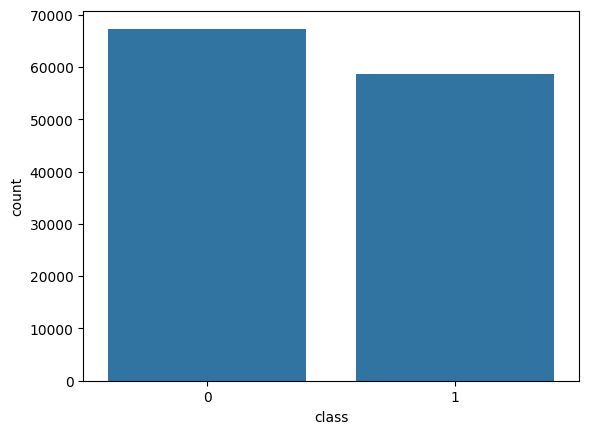

In [8]:
sns.countplot(x=train['class'])
print(train['class'].value_counts())

In [9]:
columns_to_drop = ['difficulty', 'num_outbound_cmds']
train.drop(columns=columns_to_drop, axis=1, inplace=True)
test.drop(columns=columns_to_drop, axis=1, inplace=True)


train.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label,class
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,0
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,0
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,1
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,0
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,0


In [10]:
def cod(df):
    for col in df.columns:
        if df[col].dtype == 'object': #Búsqueda de variables categóricas
            label_encoder = LabelEncoder() #Conversor de variables categóricas a variables numéricas
            df[col] = label_encoder.fit_transform(df[col])

cod(train)
cod(test)

In [11]:
from sklearn.feature_selection import SelectKBest, f_classif


# Separar las características (X) y la variable objetivo (Y)
X_train = train.drop(['class', 'label'], axis=1)
Y_train = train['class']
X_test = test.drop(['class', 'label'], axis=1)
Y_test = test['class']

# Inicializar el selector SelectKBest con la función ANOVA F-score para clasificación
selector = SelectKBest(score_func=f_classif, k=8)  

# Ajustar el selector a los datos de entrenamiento
selector.fit(X_train, Y_train)

# Obtener las características seleccionadas
selected_mask = selector.get_support()  # Booleano para cada columna
featureMap = [(i, v) for i, v in zip(selected_mask, X_train.columns)]
selectFeatures = [v for i, v in featureMap if i]

print(selectFeatures)


X_train = X_train[selectFeatures] #Filtrar el dataframe de entrenamiento para incluir solo las caractrísticas seleccionadas
X_test = X_test[selectFeatures]

['logged_in', 'serror_rate', 'srv_serror_rate', 'same_srv_rate', 'dst_host_srv_count', 'dst_host_same_srv_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate']


In [12]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Volver a convertir en DataFrame para usar .iloc después
X_train = pd.DataFrame(X_train, columns=selectFeatures)
X_test = pd.DataFrame(X_test, columns=selectFeatures)

# Barajar train y test con las etiquetas al mismo tiempo
train_shuffled = X_train.copy()
train_shuffled["label"] = Y_train.values
train_shuffled = train_shuffled.sample(frac=1, random_state=42).reset_index(drop=True)

test_shuffled = X_test.copy()
test_shuffled["label"] = Y_test.values
test_shuffled = test_shuffled.sample(frac=1, random_state=42).reset_index(drop=True)

# Separar de nuevo X e y
X_train = train_shuffled.drop("label", axis=1).iloc[:1000]
Y_train = train_shuffled["label"].iloc[:1000]

X_test = test_shuffled.drop("label", axis=1).iloc[:500]
Y_test = test_shuffled["label"].iloc[:500]

In [13]:
RANDOM_STATE = 42 
CV_FOLDS = 5
skf = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)



In [14]:
startEx=time.time()
def objective(trial):
    # Hiperparámetros a optimizar
    C = trial.suggest_float('C', 0.01, 1000, log=True)
    num_steps = trial.suggest_int('num_steps', 50, 300)
    reps = trial.suggest_int('reps', 1, 3)

    print(f"Empezando trial {trial.number} con parámetros: C={C:.4f}, num_steps={num_steps}, reps={reps}")

    
    feature_map = ZZFeatureMap(feature_dimension=8, reps=reps, entanglement='linear')
    quantum_kernel = FidelityQuantumKernel(feature_map=feature_map) 
    model = PegasosQSVC(
        quantum_kernel=quantum_kernel,
        C=C,
        num_steps=num_steps,
        precomputed=False
    )

    scores = []
    for train_idx, val_idx in skf.split(X_train, Y_train):
        model.fit(X_train.iloc[train_idx].to_numpy(), Y_train.iloc[train_idx].to_numpy())
        preds = model.predict(X_train.iloc[val_idx].to_numpy())
        score = f1_score(Y_train.iloc[val_idx], preds, average='macro')
        scores.append(score)
    return np.mean(scores)

# Optimización con Optuna
study_pegasos = optuna.create_study(direction='maximize')
study_pegasos.optimize(objective, n_trials=15)
print("Mejores parámetros encontrados:", study_pegasos.best_params)

[I 2025-11-19 09:11:33,104] A new study created in memory with name: no-name-07dac006-f44d-4010-b093-a936d396b82e


Empezando trial 0 con parámetros: C=30.4410, num_steps=106, reps=2


[I 2025-11-19 09:21:04,694] Trial 0 finished with value: 0.8536268383409498 and parameters: {'C': 30.441034254934852, 'num_steps': 106, 'reps': 2}. Best is trial 0 with value: 0.8536268383409498.


Empezando trial 1 con parámetros: C=0.0317, num_steps=276, reps=3


[I 2025-11-19 10:37:35,320] Trial 1 finished with value: 0.7317318388751946 and parameters: {'C': 0.031746215047733055, 'num_steps': 276, 'reps': 3}. Best is trial 0 with value: 0.8536268383409498.


...

Empezando trial 13 con parámetros: C=100.4372, num_steps=229, reps=1


[I 2025-11-19 13:22:27,519] Trial 13 finished with value: 0.8788586099825537 and parameters: {'C': 100.43717935602413, 'num_steps': 229, 'reps': 1}. Best is trial 13 with value: 0.8788586099825537.


Empezando trial 14 con parámetros: C=71.3004, num_steps=249, reps=1


[I 2025-11-19 13:32:27,987] Trial 14 finished with value: 0.8613565893356633 and parameters: {'C': 71.30040555598698, 'num_steps': 249, 'reps': 1}. Best is trial 13 with value: 0.8788586099825537.


Mejores parámetros encontrados: {'C': 100.43717935602413, 'num_steps': 229, 'reps': 1}


In [15]:
best_params = study_pegasos.best_params


# Define el mejor feature map con los parámetros óptimos encontrados por Optuna
best_feature_map = ZZFeatureMap(
    feature_dimension=X_train.shape[1], # Asegúrate de que X_train.shape[1] sea correcto
    reps=best_params['reps'],
    entanglement='linear'
)

# Define el quantum kernel con el mejor feature map
best_quantum_kernel = FidelityQuantumKernel(feature_map=best_feature_map)

# Inicializa el modelo PegasosQSVC final con los mejores hiperparámetros y el kernel
QSVM_model = PegasosQSVC(
    quantum_kernel=best_quantum_kernel,
    C=best_params['C'],
    num_steps=best_params['num_steps'],
    precomputed=False # Esto es correcto cuando pasas un QuantumKernel
)



start_train = time.time()
# Convierte X_train y Y_train a arrays de NumPy para el entrenamiento
QSVM_model.fit(X_train.to_numpy(), Y_train.to_numpy())
end_train = time.time()
print(f"⏱ Tiempo de entrenamiento: {end_train - start_train:.4f} segundos")

start_test = time.time()
# Convierte X_test a un array de NumPy para las predicciones
qsvm_pred = QSVM_model.predict(X_test.to_numpy())
end_test = time.time()
print(f"⏱ Tiempo de testeo: {end_test - start_test:.4f} segundos")

# También convierte Y_test a NumPy para calcular las métricas si es una Serie/DataFrame
print(f"\n✅ F1-score QSVM en test: {f1_score(Y_test.to_numpy(), qsvm_pred, average='macro'):.4f}")
print(f"✅ Accuracy QSVM en test: {accuracy_score(Y_test.to_numpy(), qsvm_pred):.4f}")
print("\n📊 Reporte de clasificación QSVM:\n", classification_report(Y_test.to_numpy(), qsvm_pred))

endEx=time.time()
print(f"⏱ Tiempo de ejecución total: {endEx - startEx:.4f} segundos")

⏱ Tiempo de entrenamiento: 35.6090 segundos
⏱ Tiempo de testeo: 152.7512 segundos

✅ F1-score QSVM en test: 0.6498
✅ Accuracy QSVM en test: 0.6540

📊 Reporte de clasificación QSVM:
               precision    recall  f1-score   support

           0       0.54      0.96      0.69       199
           1       0.94      0.45      0.61       301

    accuracy                           0.65       500
   macro avg       0.74      0.71      0.65       500
weighted avg       0.78      0.65      0.64       500

⏱ Tiempo de ejecución total: 15843.2609 segundos


Calculando función de decisión...


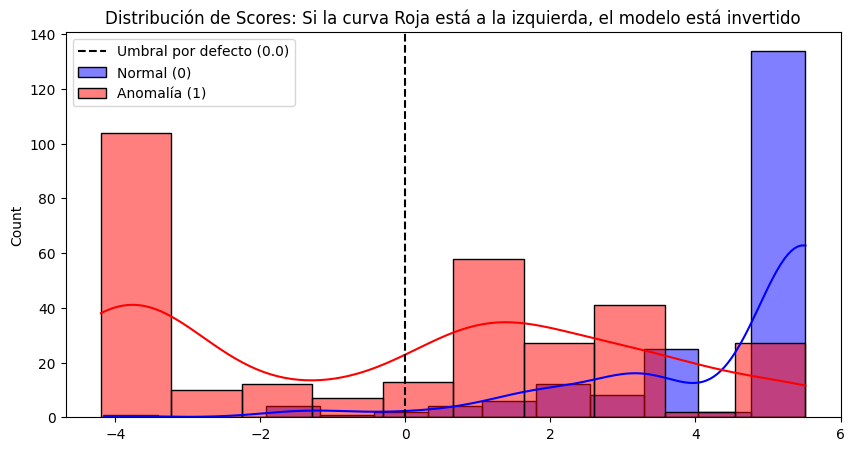

🔍 El Umbral Óptimo encontrado es: -2.517312605807609

✅ Matriz de Confusión (Optimizada):


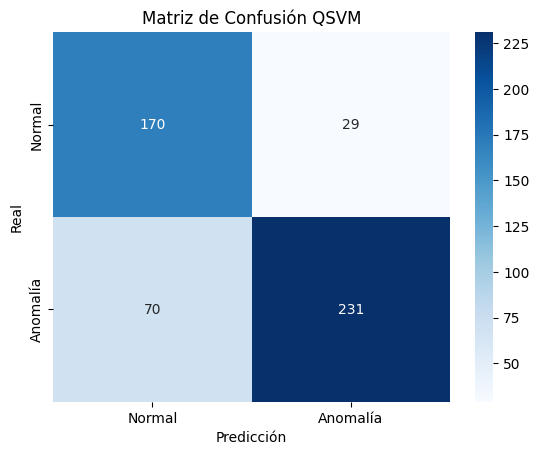


📊 Reporte de Clasificación (Optimizado):
              precision    recall  f1-score   support

           0       0.71      0.85      0.77       199
           1       0.89      0.77      0.82       301

    accuracy                           0.80       500
   macro avg       0.80      0.81      0.80       500
weighted avg       0.82      0.80      0.80       500



In [23]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, f1_score, roc_curve

# PASO 1: Obtener los puntajes de decisión puros
# Esto saca los valores numéricos que usa el modelo antes de decidir "0" o "1"
print("Calculando función de decisión...")
y_scores = QSVM_model.decision_function(X_test.to_numpy())

#PASO 2: Visualizar el problema (Histograma)
plt.figure(figsize=(10, 5))
sns.histplot(y_scores[Y_test==0], color='blue', label='Normal (0)', kde=True, alpha=0.5)
sns.histplot(y_scores[Y_test==1], color='red', label='Anomalía (1)', kde=True, alpha=0.5)
plt.axvline(0, color='black', linestyle='--', label='Umbral por defecto (0.0)')
plt.title('Distribución de Scores: Si la curva Roja está a la izquierda, el modelo está invertido')
plt.legend()
plt.show()

#PASO 3: Calcular el Umbral Óptimo
# Usamos -y_scores porque la relación está invertida
scores_para_roc = -y_scores 

fpr, tpr, thresholds = roc_curve(Y_test, scores_para_roc)
J = tpr - fpr
ix = np.argmax(J)
best_thresh = thresholds[ix]

print(f"🔍 El Umbral Óptimo encontrado es: {best_thresh}")

# PASO 4: Aplicar el nuevo umbral para predecir
# Lógica: Si el score (invertido) es mayor al umbral, es anomalía
y_pred_optimo = (scores_para_roc >= best_thresh).astype(int)

# PASO 5: Mostrar los Nuevos Resultados
print("\n✅ Matriz de Confusión (Optimizada):")
cm = confusion_matrix(Y_test, y_pred_optimo)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Normal', 'Anomalía'], yticklabels=['Normal', 'Anomalía'])
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.title('Matriz de Confusión QSVM')
plt.show()

print("\n📊 Reporte de Clasificación (Optimizado):")
print(classification_report(Y_test, y_pred_optimo))

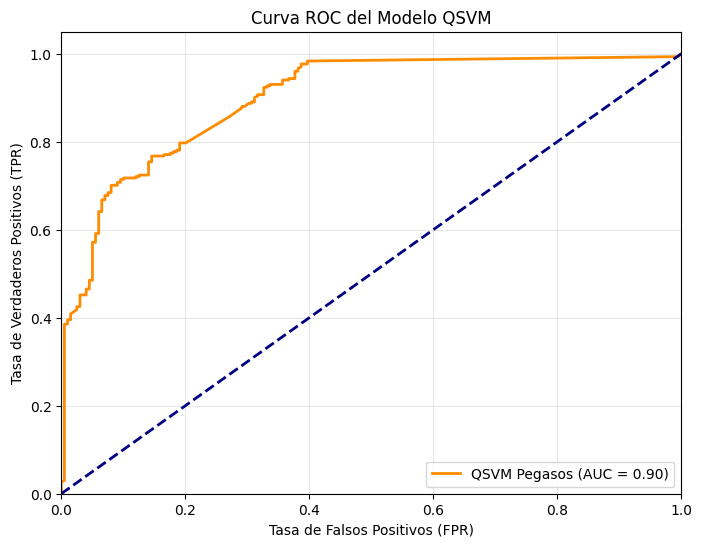

✅ Área Bajo la Curva (AUC): 0.8983


In [25]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt


# -y_scores (negativo) porque el modelo invirtió las clases.
scores_para_roc = -y_scores 

# Calcular FPR, TPR y AUC
fpr, tpr, thresholds = roc_curve(Y_test, scores_para_roc)
roc_auc = auc(fpr, tpr)

# Graficar
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'QSVM Pegasos (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--') # Línea de azar

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curva ROC del Modelo QSVM')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()

print(f"✅ Área Bajo la Curva (AUC): {roc_auc:.4f}")